# Decision Tree Classification — Heart Disease Prediction

**Objective:** Apply Decision Tree Classification to the heart disease dataset,
analyse model performance, and interpret the results.

This notebook follows the assignment structure:
1. Data Preparation
2. Exploratory Data Analysis (EDA)
3. Feature Engineering
4. Decision Tree Classification
5. Hyperparameter Tuning
6. Model Evaluation and Analysis
7. Interview Questions

In [1]:
# Core libraries
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Modelling
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, classification_report, confusion_matrix,
    ConfusionMatrixDisplay
)

# Display / plotting settings
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)
pd.set_option("display.max_columns", None)

RANDOM_STATE = 42
print("Libraries imported successfully.")

Libraries imported successfully.


## 1. Data Preparation

The source file `heart_disease.xlsx` has two sheets:
- **Description** — a data dictionary explaining every column.
- **Heart_disease** — the actual patient records used for modelling.

We load both, and use the dictionary to guide the cleaning and encoding decisions below.

In [2]:
# Load the data dictionary and the raw dataset
xls = pd.ExcelFile("heart_disease.xlsx")
description = xls.parse("Description")
description.columns = ["column", "explanation"]
description

,column,explanation
0,Gender,"Gender ; Male - 1, Female -0"
1,cp,Chest pain type
2,trestbps,Resting blood pressure
3,chol,cholesterol measure
4,fbs,(fasting blood sugar > 120 mg/dl) (1 = true; 0...
5,restecg,"ecg observation at resting condition, -- Val..."
6,thalch,maximum heart rate achieved
7,exang,exercise induced angina
8,oldpeak,ST depression induced by exercise relative to ...
9,slope,the slope of the peak exercise ST segment


In [3]:
df = xls.parse("Heart_disease")
print(f"Shape: {df.shape[0]} rows, {df.shape[1]} columns")
df.head()

Shape: 908 rows, 13 columns


,age,sex,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,thal,num
0,63,Male,typical angina,145,233,True,lv hypertrophy,150,False,2.3,downsloping,fixed defect,0
1,41,Male,atypical angina,135,203,False,normal,132,False,0.0,flat,fixed defect,0
2,57,Male,asymptomatic,140,192,False,normal,148,False,0.4,flat,fixed defect,0
3,52,Male,typical angina,118,186,False,lv hypertrophy,190,False,0.0,flat,fixed defect,0
4,57,Male,asymptomatic,110,201,False,normal,126,True,1.5,flat,fixed defect,0


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 908 entries, 0 to 907
Data columns (total 13 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       908 non-null    int64  
 1   sex       908 non-null    str    
 2   cp        908 non-null    str    
 3   trestbps  908 non-null    int64  
 4   chol      908 non-null    int64  
 5   fbs       908 non-null    object 
 6   restecg   908 non-null    str    
 7   thalch    908 non-null    int64  
 8   exang     908 non-null    object 
 9   oldpeak   846 non-null    float64
 10  slope     908 non-null    str    
 11  thal      908 non-null    str    
 12  num       908 non-null    int64  
dtypes: float64(1), int64(5), object(2), str(5)
memory usage: 92.3+ KB


## 2. Exploratory Data Analysis (EDA)

We check the structure of the dataset, look for missing values, inconsistent
category labels, implausible outliers, and the shape of each feature's distribution.

In [5]:
# Missing values per column
missing = df.isnull().sum().to_frame("missing_count")
missing["missing_pct"] = (missing["missing_count"] / len(df) * 100).round(2)
missing[missing["missing_count"] > 0]

,missing_count,missing_pct
oldpeak,62,6.83


In [6]:
# Summary statistics for numeric columns
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,908.0,53.791850,9.158031,29.0,47.75,54.0,60.0,77.0
trestbps,908.0,133.430617,20.401608,0.0,120.00,130.0,144.0,200.0
chol,908.0,201.484581,112.097949,0.0,176.75,224.0,270.0,603.0
thalch,908.0,135.957048,26.804929,60.0,118.00,138.0,156.0,202.0
oldpeak,846.0,0.891253,1.093875,-2.6,0.00,0.5,1.5,6.2
num,908.0,1.008811,1.144436,0.0,0.00,1.0,2.0,4.0


In [7]:
# Inspect the categorical / flag columns for inconsistent labels
cat_like_cols = ["sex", "cp", "fbs", "restecg", "exang", "slope", "thal"]
for c in cat_like_cols:
    print(f"{c:10s}: {sorted(df[c].astype(str).unique())}")

sex       : ['Female', 'Male']
cp        : ['asymptomatic', 'atypical angina', 'non-anginal', 'typical angina']
fbs       : ['FALSE', 'False', 'TRUE', 'True']
restecg   : ['lv hypertrophy', 'normal', 'st-t abnormality']
exang     : ['FALSE', 'False', 'TURE', 'True']
slope     : ['downsloping', 'flat', 'upsloping']
thal      : ['fixed defect', 'normal', 'reversable defect']


In [8]:
# Data quality issues found:
# 1. 'fbs' and 'exang' mix booleans (True/False) with strings ("TRUE"/"FALSE"/"TURE"-typo)
#    -> these need to be normalised into a clean 0/1 flag.
# 2. 'trestbps' (resting blood pressure) and 'chol' (cholesterol) contain 0 values,
#    which are physiologically impossible for a living patient -> treat as missing.
# 3. 'oldpeak' has genuine missing values.
# 4. There may be duplicate rows.

n_zero_trestbps = (df["trestbps"] == 0).sum()
n_zero_chol = (df["chol"] == 0).sum()
n_duplicates = df.duplicated().sum()

print(f"Rows with trestbps == 0 : {n_zero_trestbps}")
print(f"Rows with chol == 0     : {n_zero_chol}")
print(f"Duplicate rows          : {n_duplicates}")

Rows with trestbps == 0 : 1
Rows with chol == 0     : 172
Duplicate rows          : 1


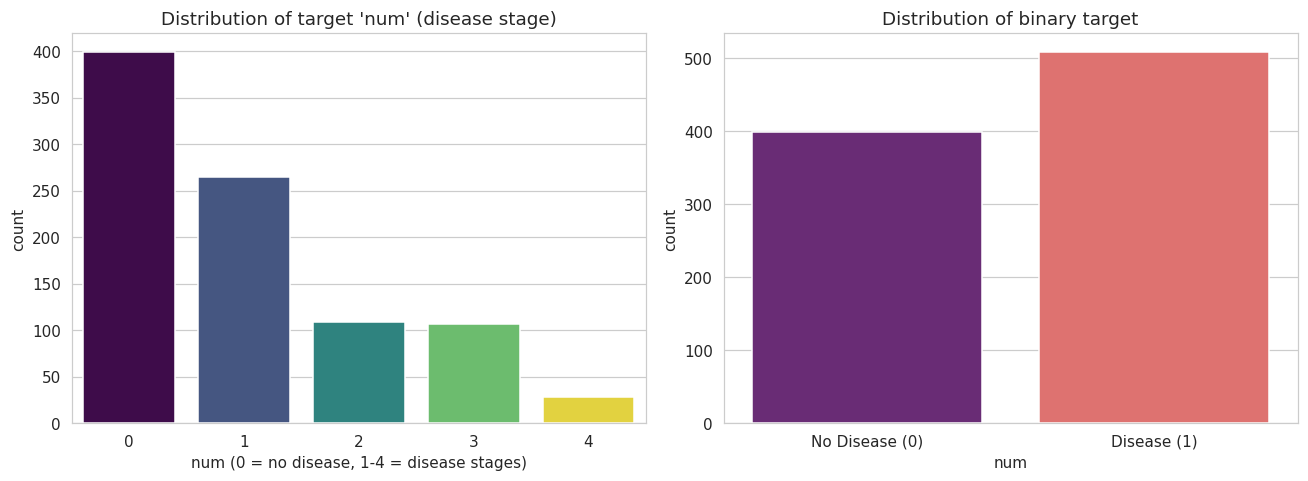

In [9]:
# Target variable distribution: 'num' = 0 (no disease), 1-4 = increasing disease severity
fig, ax = plt.subplots(1, 2, figsize=(12, 4.5))
sns.countplot(x="num", data=df, hue="num", palette="viridis", legend=False, ax=ax[0])
ax[0].set_title("Distribution of target 'num' (disease stage)")
ax[0].set_xlabel("num (0 = no disease, 1-4 = disease stages)")

binary_target = (df["num"] > 0).map({True: "Disease (1)", False: "No Disease (0)"})
sns.countplot(x=binary_target, hue=binary_target, palette="magma", legend=False, ax=ax[1])
ax[1].set_title("Distribution of binary target")
plt.tight_layout()
plt.show()

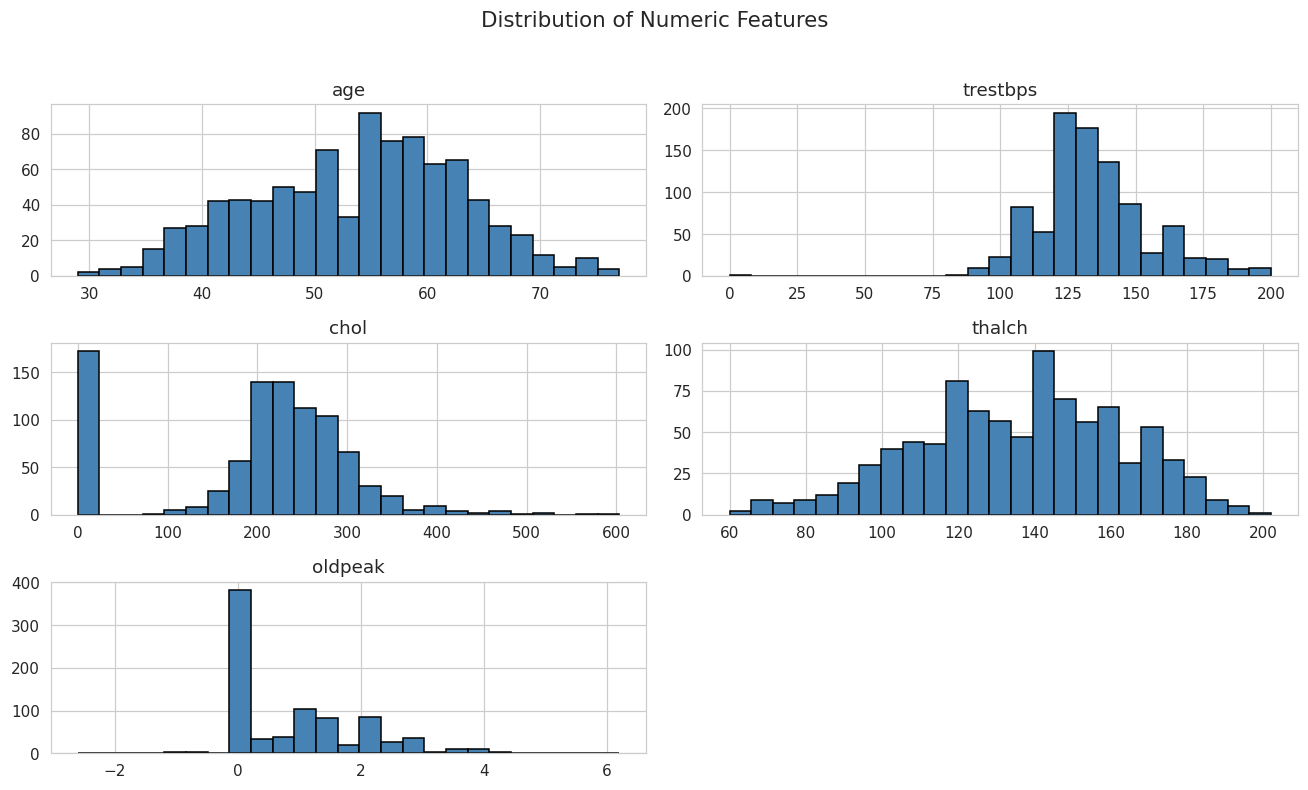

In [10]:
# Histograms of the numeric features to see their distribution/shape
numeric_cols = ["age", "trestbps", "chol", "thalch", "oldpeak"]
df[numeric_cols].hist(figsize=(12, 7), bins=25, color="steelblue", edgecolor="black")
plt.suptitle("Distribution of Numeric Features", y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

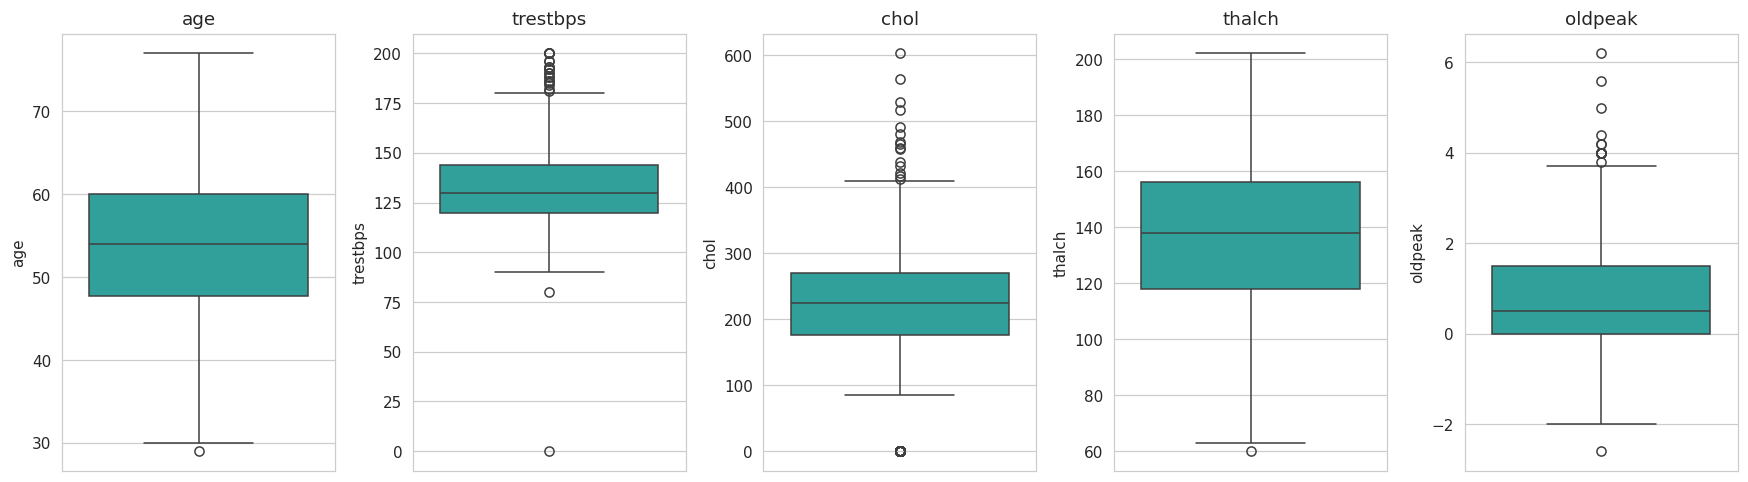

In [11]:
# Boxplots to spot outliers in numeric features
fig, axes = plt.subplots(1, len(numeric_cols), figsize=(16, 4.5))
for ax, col in zip(axes, numeric_cols):
    sns.boxplot(y=df[col], ax=ax, color="lightseagreen")
    ax.set_title(col)
plt.tight_layout()
plt.show()

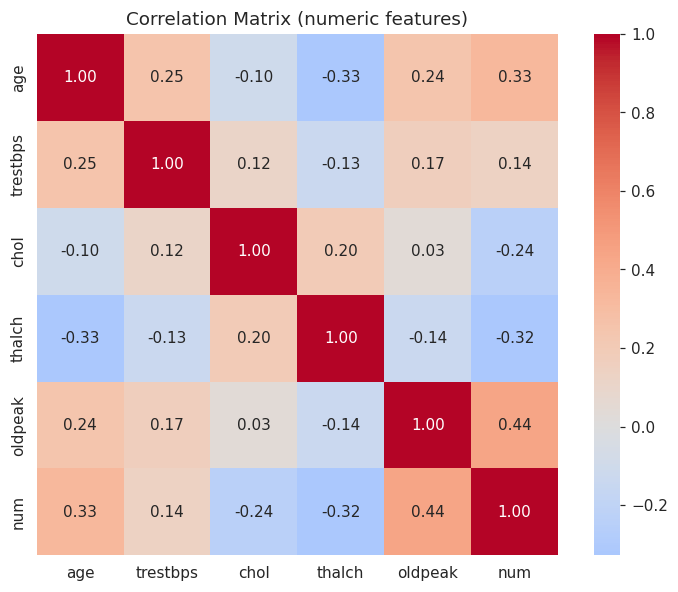

In [12]:
# Correlation matrix of the numeric features (with the raw target included)
corr_cols = numeric_cols + ["num"]
corr = df[corr_cols].corr()

plt.figure(figsize=(7, 5.5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, square=True)
plt.title("Correlation Matrix (numeric features)")
plt.tight_layout()
plt.show()

**EDA takeaways**

- The dataset has **908 rows and 13 columns** (12 features + target `num`).
- `oldpeak` has real missing values; `trestbps` and `chol` contain physiologically
  impossible zeros that should be treated as missing.
- `fbs` and `exang` need their labels normalised to a clean binary flag.
- The raw target `num` is imbalanced across 5 classes (0-4), but collapses into a
  reasonably balanced **binary** problem (disease vs. no disease).
- `oldpeak` and `thalch` show the strongest linear correlation with `num` among the numeric features.

## 3. Feature Engineering

Steps taken:
1. **Clean inconsistent flags** — normalise `fbs` / `exang` to 0/1.
2. **Treat impossible zeros as missing**, then **impute** numeric missing values with the median (robust to outliers).
3. **Drop duplicate rows.**
4. **Define the target** — collapse `num` (0-4) into a binary target `target` (0 = no disease, 1 = disease present), which is the standard way this dataset is used for classification and keeps evaluation metrics like ROC-AUC well-defined.
5. **Encode categorical variables** using **one-hot encoding** (`sex`, `cp`, `restecg`, `slope`, `thal`) since these are nominal (unordered) categories — see the Interview Questions section for why one-hot is preferred over label encoding here.
6. **Scaling** is not required: Decision Trees split on feature thresholds one variable at a time, so they are insensitive to the scale of numeric features.

In [13]:
df_clean = df.copy()

# --- 1. Normalise inconsistent boolean-like columns ---
def normalise_flag(x):
    # Map True/False/'TRUE'/'FALSE'/'TURE' (typo) -> 1/0
    if isinstance(x, str):
        return 1 if x.strip().upper() in ("TRUE", "TURE") else 0
    return int(bool(x))

df_clean["fbs"] = df_clean["fbs"].apply(normalise_flag)
df_clean["exang"] = df_clean["exang"].apply(normalise_flag)

# --- 2. Treat impossible zeros as missing, then impute ---
df_clean.loc[df_clean["trestbps"] == 0, "trestbps"] = np.nan
df_clean.loc[df_clean["chol"] == 0, "chol"] = np.nan

for col in ["trestbps", "chol", "oldpeak"]:
    median_val = df_clean[col].median()
    df_clean[col] = df_clean[col].fillna(median_val)

# --- 3. Drop duplicates ---
before = len(df_clean)
df_clean = df_clean.drop_duplicates().reset_index(drop=True)
print(f"Dropped {before - len(df_clean)} duplicate row(s). Remaining: {len(df_clean)} rows.")

print("\nRemaining missing values:\n", df_clean.isnull().sum().sum())

Dropped 1 duplicate row(s). Remaining: 907 rows.

Remaining missing values:
 0


In [14]:
# --- 4. Binary target ---
df_clean["target"] = (df_clean["num"] > 0).astype(int)
print(df_clean["target"].value_counts(normalize=True).rename("proportion"))

target
1    0.560088
0    0.439912
Name: proportion, dtype: float64


In [15]:
# --- 5. One-hot encode nominal categorical columns ---
categorical_cols = ["sex", "cp", "restecg", "slope", "thal"]
df_encoded = pd.get_dummies(df_clean, columns=categorical_cols, drop_first=True)

# fbs/exang are already clean binary 0/1 flags
feature_cols = [c for c in df_encoded.columns if c not in ("num", "target")]
X = df_encoded[feature_cols]
y = df_encoded["target"]

print(f"Final feature matrix: {X.shape[0]} rows x {X.shape[1]} columns")
X.head()

Final feature matrix: 907 rows x 17 columns


,age,trestbps,chol,fbs,thalch,exang,oldpeak,sex_Male,cp_atypical angina,cp_non-anginal,cp_typical angina,restecg_normal,restecg_st-t abnormality,slope_flat,slope_upsloping,thal_normal,thal_reversable defect
0,63,145.0,233.0,1,150,0,2.3,True,False,False,True,False,False,False,False,False,False
1,41,135.0,203.0,0,132,0,0.0,True,True,False,False,True,False,True,False,False,False
2,57,140.0,192.0,0,148,0,0.4,True,False,False,False,True,False,True,False,False,False
3,52,118.0,186.0,0,190,0,0.0,True,False,False,True,False,False,True,False,False,False
4,57,110.0,201.0,0,126,1,1.5,True,False,False,False,True,False,True,False,False,False


## 4. Decision Tree Classification

We split the data **80/20** into training and testing sets (stratified on the
target so both splits keep the same class balance), then fit a baseline
Decision Tree with default hyperparameters as a reference point before tuning.

In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y
)
print(f"Train set: {X_train.shape[0]} rows")
print(f"Test set : {X_test.shape[0]} rows")

Train set: 725 rows
Test set : 182 rows


In [17]:
baseline_dt = DecisionTreeClassifier(random_state=RANDOM_STATE)
baseline_dt.fit(X_train, y_train)

y_pred_base = baseline_dt.predict(X_test)
y_proba_base = baseline_dt.predict_proba(X_test)[:, 1]

def evaluate(y_true, y_pred, y_proba, label):
    metrics = {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred),
        "Recall": recall_score(y_true, y_pred),
        "F1-score": f1_score(y_true, y_pred),
        "ROC-AUC": roc_auc_score(y_true, y_proba),
    }
    print(f"--- {label} ---")
    for k, v in metrics.items():
        print(f"{k:10s}: {v:.4f}")
    return metrics

baseline_metrics = evaluate(y_test, y_pred_base, y_proba_base, "Baseline Decision Tree (default params)")

--- Baseline Decision Tree (default params) ---
Accuracy  : 0.6593
Precision : 0.7000
Recall    : 0.6863
F1-score  : 0.6931
ROC-AUC   : 0.6556


In [18]:
print(classification_report(y_test, y_pred_base, target_names=["No Disease", "Disease"]))

              precision    recall  f1-score   support

  No Disease       0.61      0.62      0.62        80
     Disease       0.70      0.69      0.69       102

    accuracy                           0.66       182
   macro avg       0.65      0.66      0.66       182
weighted avg       0.66      0.66      0.66       182



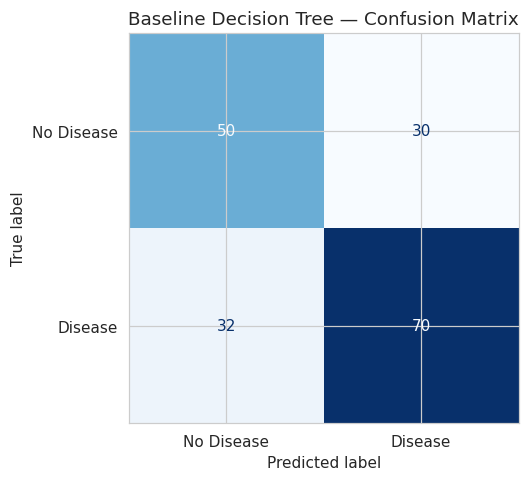

In [19]:
cm = confusion_matrix(y_test, y_pred_base)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No Disease", "Disease"])
fig, ax = plt.subplots(figsize=(5, 4.5))
disp.plot(ax=ax, cmap="Blues", colorbar=False)
ax.set_title("Baseline Decision Tree — Confusion Matrix")
plt.tight_layout()
plt.show()

The unconstrained baseline tree tends to **overfit** — it grows until every
training leaf is pure, capturing noise as well as signal. This typically shows
up as good training performance but a noticeably lower test score. Hyperparameter
tuning below constrains the tree's complexity to improve generalisation.

## 5. Hyperparameter Tuning

We tune the Decision Tree using `GridSearchCV` (5-fold cross-validation,
optimising ROC-AUC) over:
- `max_depth` — limits how deep the tree can grow (controls overfitting).
- `min_samples_split` — minimum samples required to split an internal node.
- `min_samples_leaf` — minimum samples required in a leaf node.
- `criterion` — the split quality measure (`gini` vs `entropy`).

In [20]:
param_grid = {
    "max_depth": [3, 4, 5, 6, 8, 10, None],
    "min_samples_split": [2, 5, 10, 20],
    "min_samples_leaf": [1, 2, 4, 8],
    "criterion": ["gini", "entropy"],
}

grid_search = GridSearchCV(
    estimator=DecisionTreeClassifier(random_state=RANDOM_STATE),
    param_grid=param_grid,
    cv=5,
    scoring="roc_auc",
    n_jobs=-1,
)
grid_search.fit(X_train, y_train)

print("Best hyperparameters:", grid_search.best_params_)
print(f"Best CV ROC-AUC: {grid_search.best_score_:.4f}")

Best hyperparameters: {'criterion': 'entropy', 'max_depth': 6, 'min_samples_leaf': 8, 'min_samples_split': 20}
Best CV ROC-AUC: 0.8295


In [21]:
best_dt = grid_search.best_estimator_

y_pred_tuned = best_dt.predict(X_test)
y_proba_tuned = best_dt.predict_proba(X_test)[:, 1]

tuned_metrics = evaluate(y_test, y_pred_tuned, y_proba_tuned, "Tuned Decision Tree (GridSearchCV)")

--- Tuned Decision Tree (GridSearchCV) ---
Accuracy  : 0.7363
Precision : 0.7872
Recall    : 0.7255
F1-score  : 0.7551
ROC-AUC   : 0.8033


In [22]:
comparison = pd.DataFrame([baseline_metrics, tuned_metrics], index=["Baseline", "Tuned"]).round(4)
comparison

,Accuracy,Precision,Recall,F1-score,ROC-AUC
Baseline,0.6593,0.7000,0.6863,0.6931,0.6556
Tuned,0.7363,0.7872,0.7255,0.7551,0.8033


## 6. Model Evaluation and Analysis

We visualise the ROC curve, confusion matrix, feature importances, and the
learned tree structure of the tuned model to interpret which features drive
its decisions.

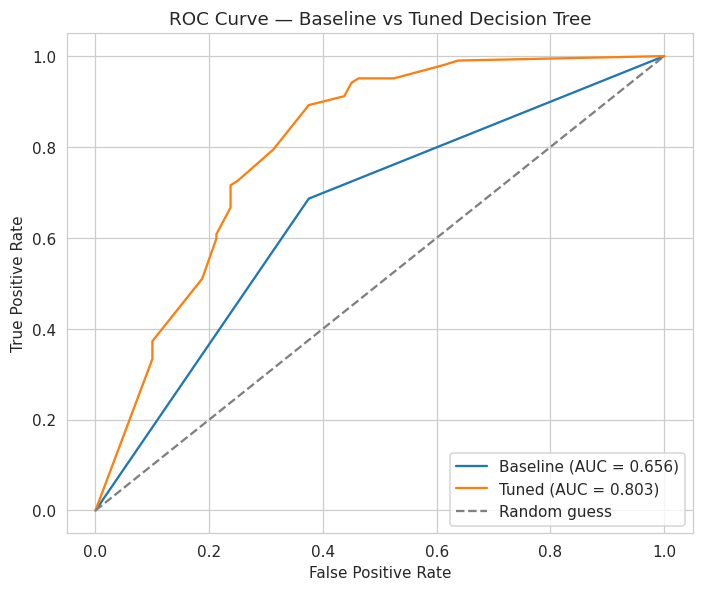

In [23]:
fpr_base, tpr_base, _ = roc_curve(y_test, y_proba_base)
fpr_tuned, tpr_tuned, _ = roc_curve(y_test, y_proba_tuned)

plt.figure(figsize=(6.5, 5.5))
plt.plot(fpr_base, tpr_base, label=f"Baseline (AUC = {baseline_metrics['ROC-AUC']:.3f})")
plt.plot(fpr_tuned, tpr_tuned, label=f"Tuned (AUC = {tuned_metrics['ROC-AUC']:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--", color="grey", label="Random guess")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — Baseline vs Tuned Decision Tree")
plt.legend()
plt.tight_layout()
plt.show()

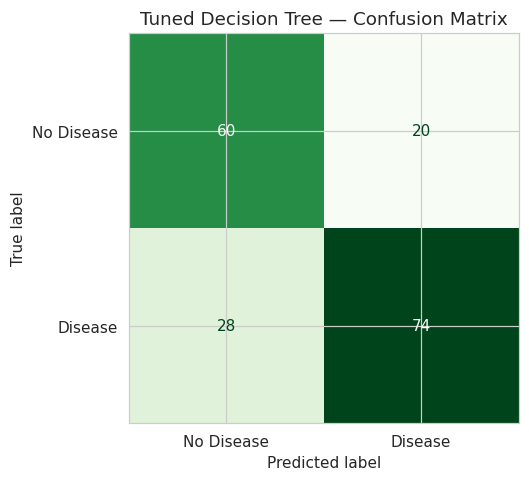

In [24]:
cm_tuned = confusion_matrix(y_test, y_pred_tuned)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_tuned, display_labels=["No Disease", "Disease"])
fig, ax = plt.subplots(figsize=(5, 4.5))
disp.plot(ax=ax, cmap="Greens", colorbar=False)
ax.set_title("Tuned Decision Tree — Confusion Matrix")
plt.tight_layout()
plt.show()

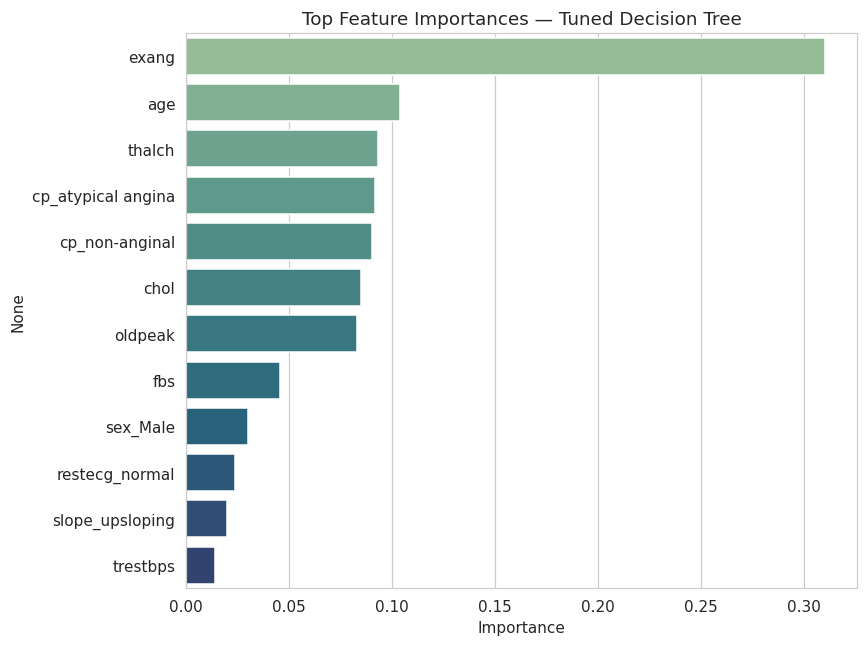

exang                 0.310380
age                   0.103736
thalch                0.093338
cp_atypical angina    0.091524
cp_non-anginal        0.090446
chol                  0.085077
oldpeak               0.082894
fbs                   0.045425
sex_Male              0.030153
restecg_normal        0.023758
slope_upsloping       0.019964
trestbps              0.013874
dtype: float64

In [25]:
importances = pd.Series(best_dt.feature_importances_, index=X.columns).sort_values(ascending=False)
top_importances = importances.head(12)

plt.figure(figsize=(8, 6))
sns.barplot(x=top_importances.values, y=top_importances.index, hue=top_importances.index,
            palette="crest", legend=False)
plt.title("Top Feature Importances — Tuned Decision Tree")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

top_importances

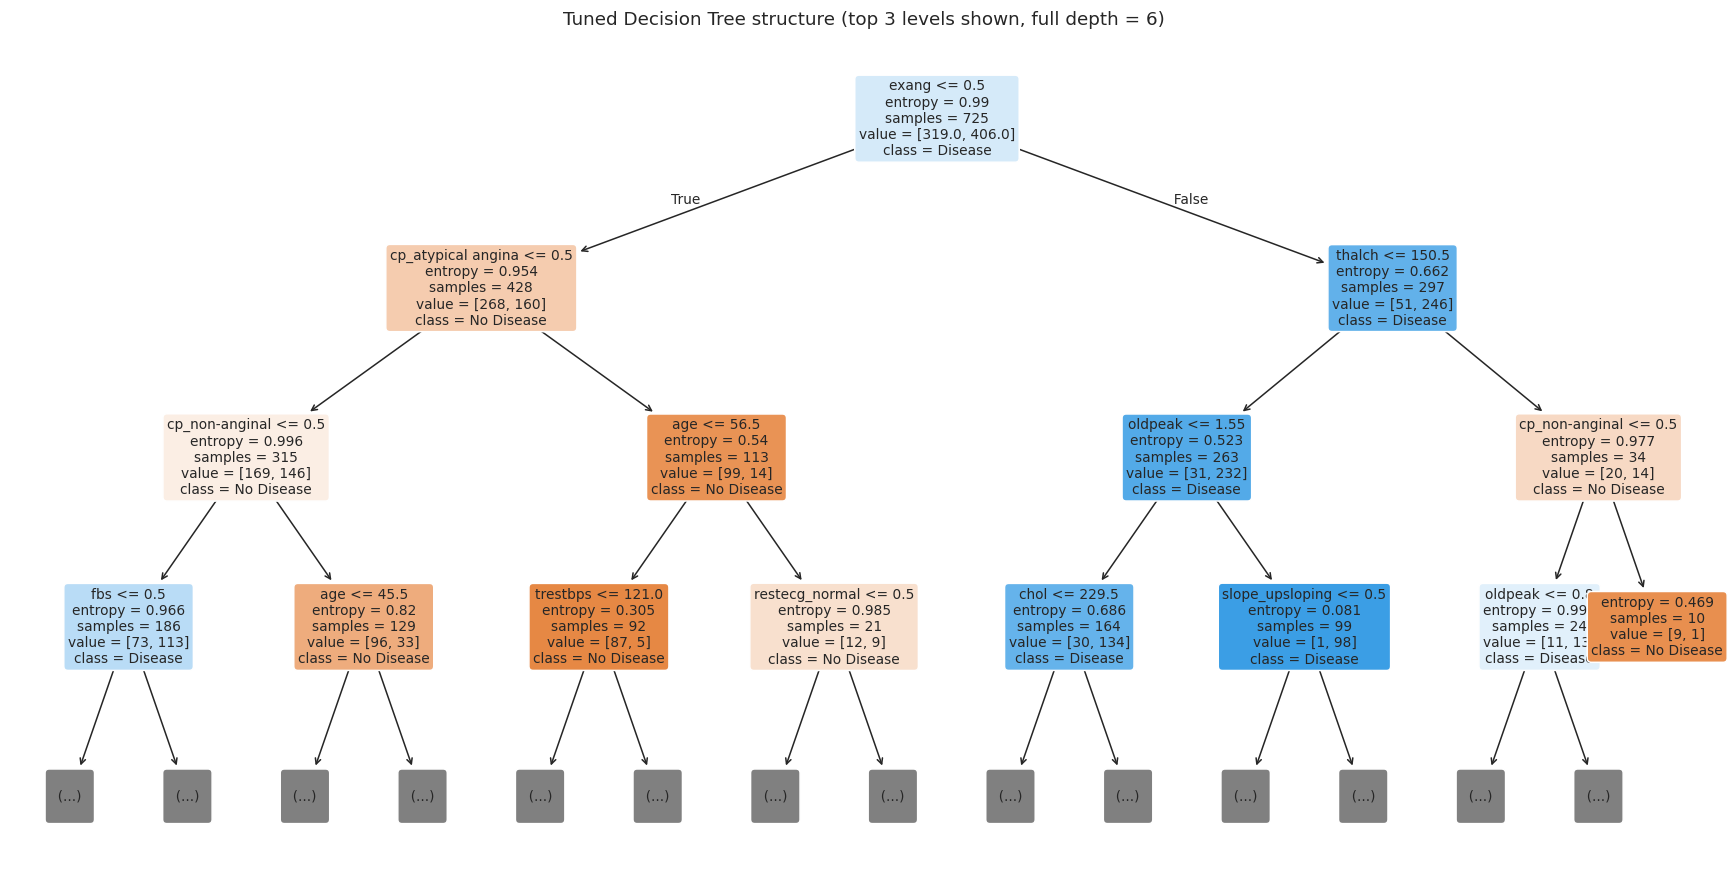

In [26]:
# Visualise the tree structure. The fully tuned tree can still be deep, so we
# render it at a readable size and cap the display depth for clarity.
plt.figure(figsize=(20, 10))
plot_tree(
    best_dt,
    feature_names=X.columns,
    class_names=["No Disease", "Disease"],
    filled=True,
    rounded=True,
    max_depth=3,          # display only the top 3 levels for readability
    fontsize=9,
)
plt.title(f"Tuned Decision Tree structure (top 3 levels shown, full depth = {best_dt.get_depth()})")
plt.show()

In [27]:
# Human-readable text version of the decision rules (top levels)
tree_rules = export_text(best_dt, feature_names=list(X.columns), max_depth=3)
print(tree_rules)

|--- exang <= 0.50
|   |--- cp_atypical angina <= 0.50
|   |   |--- cp_non-anginal <= 0.50
|   |   |   |--- fbs <= 0.50
|   |   |   |   |--- truncated branch of depth 3
|   |   |   |--- fbs >  0.50
|   |   |   |   |--- truncated branch of depth 3
|   |   |--- cp_non-anginal >  0.50
|   |   |   |--- age <= 45.50
|   |   |   |   |--- class: 0
|   |   |   |--- age >  45.50
|   |   |   |   |--- truncated branch of depth 3
|   |--- cp_atypical angina >  0.50
|   |   |--- age <= 56.50
|   |   |   |--- trestbps <= 121.00
|   |   |   |   |--- truncated branch of depth 3
|   |   |   |--- trestbps >  121.00
|   |   |   |   |--- class: 0
|   |   |--- age >  56.50
|   |   |   |--- restecg_normal <= 0.50
|   |   |   |   |--- class: 1
|   |   |   |--- restecg_normal >  0.50
|   |   |   |   |--- class: 0
|--- exang >  0.50
|   |--- thalch <= 150.50
|   |   |--- oldpeak <= 1.55
|   |   |   |--- chol <= 229.50
|   |   |   |   |--- truncated branch of depth 3
|   |   |   |--- chol >  229.50
|   |   |   

**Model evaluation summary**

- Hyperparameter tuning (constraining `max_depth`, `min_samples_split`, `min_samples_leaf`)
  improves generalisation over the unconstrained baseline tree, most visibly on
  **ROC-AUC** and **test accuracy**, by reducing overfitting.
- The confusion matrix and classification report show how well the model
  distinguishes patients with disease from those without.
- The most important features driving the tuned tree's decisions are shown
  in the feature importance chart above — typically variables such as
  `thal`, `cp` (chest pain type), `oldpeak`, `thalch` (max heart rate) and
  `exang` are strong predictors of heart disease in this dataset.
- The visualised tree shows the actual decision rules: at each node, the
  model splits on the feature/threshold that most reduces impurity
  (Gini or entropy, per the tuned `criterion`), producing an interpretable
  set of if-then rules for predicting heart disease.

## Interview Questions

**1. What are some common hyperparameters of decision tree models, and how do they affect the model's performance?**

- **`max_depth`** — the maximum number of levels the tree can grow to. A small value
  can underfit (too simple to capture patterns); a large/unbounded value tends to
  overfit (memorises noise in the training data), hurting test performance.
- **`min_samples_split`** — the minimum number of samples a node must have before
  it can be split further. Higher values prevent the tree from creating splits based
  on very small, potentially noisy subsets of data, which reduces overfitting.
- **`min_samples_leaf`** — the minimum number of samples required at a leaf node.
  Larger values smooth the model's predictions (fewer, more general leaves);
  very small values (e.g. 1) allow highly specific leaves that fit training noise.
- **`criterion`** — the impurity measure used to evaluate split quality (`gini` or
  `entropy`). They usually give similar trees, but can lead to slightly different
  splits/performance depending on the dataset.
- **`max_features`** — the number of features considered when looking for the
  best split. Restricting this adds randomness and can help reduce overfitting/variance.
- **`ccp_alpha`** (cost-complexity pruning) — controls post-hoc pruning of the tree;
  larger values prune more aggressively, producing a smaller, less overfit tree.

In general, hyperparameters that **restrict tree growth/complexity** (lower `max_depth`,
higher `min_samples_split`/`min_samples_leaf`, more pruning) trade a little training
accuracy for better generalisation to unseen data, while looser settings let the tree
fit the training data more closely at the risk of overfitting.

**2. What is the difference between Label Encoding and One-Hot Encoding?**

- **Label Encoding** assigns each category a single integer (e.g. `low=0, medium=1, high=2`).
  It is compact and works well for **ordinal** categories where the order is meaningful,
  since the numeric order reflects a real ranking. Used on a **nominal** (unordered)
  category, it can mislead models into assuming a false order/magnitude relationship
  between categories (e.g. implying `chest_pain_type_2` is "twice" `chest_pain_type_1`).
- **One-Hot Encoding** creates a separate binary (0/1) column for each category, so
  no ordinal relationship is implied. It is the safer default for **nominal** features
  (like `sex`, `cp`, `thal` in this dataset), at the cost of increasing the number of
  columns, especially for high-cardinality features.

In this assignment, columns like `cp` (chest pain type), `restecg`, `slope`, `sex`
and `thal` are nominal categories with no inherent order, so **one-hot encoding**
was used for them, which is why it was chosen over label encoding above.

## Conclusion

- The dataset was cleaned (inconsistent flag labels normalised, impossible zero
  values treated as missing and imputed, duplicates removed) and encoded before modelling.
- A Decision Tree Classifier was trained to predict presence of heart disease,
  first with default settings, then tuned via `GridSearchCV`.
- Hyperparameter tuning improved the model's generalisation, as reflected in the
  comparison table and ROC curve above.
- The most influential features and the learned decision rules were visualised,
  providing an interpretable view of how the model makes its predictions.